In [1]:
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import ROOT

In [2]:
file = '/eos/user/b/bbapi/MC_contacts/2024_signal_samples_WH/CMSSW_15_0_15/src/WH_2024_M15.root'
factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events = factory.events()

M = 15

In [3]:
def delta_r_manual(obj1, obj2):
    deta = obj1.eta[:, None] - obj2.eta
    dphi = np.abs(obj1.phi[:, None] - obj2.phi)
    dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    return np.sqrt(deta**2 + dphi**2)

In [ ]:
def photon_preselections(
    photons: ak.Array,
    jets: ak.Array,
    electrons: ak.Array,
    muons: ak.Array,
    events: ak.Array,
    electron_veto=True,
    revert_electron_veto=False,
    year="2018",
    wp_medium=0.2783,
    IsFlag=False):
    """
    Apply full preselection on leptons, jets, and photons.
    Finally return only photons from events that pass all criteria.
    """

    print("Number of events before preselection:", len(events))

    # ------------------------
    # Lepton selection
    # ------------------------
    if year.startswith("2016"):
        ele_pt_cut, mu_pt_cut = 27, 26
    elif year == "2017":
        ele_pt_cut, mu_pt_cut = 33, 29
    elif year == "2018":
        # ele_pt_cut, mu_pt_cut = 33, 26
        ele_pt_cut, mu_pt_cut = 33, 26
    elif year == "2024":
        # ele_pt_cut, mu_pt_cut = 33, 26
        ele_pt_cut, mu_pt_cut = 30, 24

    else:
        raise ValueError(f"Unknown year {year}")

    # electrons = events.Electron

    good_electrons = (
        (electrons.pt > ele_pt_cut) &
        (np.abs(electrons.eta) < 2.5) &  # keep within tracker acceptance
        ~((np.abs(electrons.eta) > 1.44) & (np.abs(electrons.eta) < 1.57)) &  # remove transition
        (electrons.mvaIso_WP80) &        # tight MVA ID
        (electrons.pfRelIso03_all < 0.15)  # isolation cut
    )

    good_muons = (
        (muons.pt > mu_pt_cut)
        & (np.abs(muons.eta) < 2.4)
        & (muons.pfRelIso03_all < 0.15)
    )

    one_ele = ak.num(electrons[good_electrons]) == 1
    one_mu = ak.num(muons[good_muons]) == 1
    lepton_channel_mask = one_ele | one_mu
    # lepton_channel_mask = one_mu

    selected_electrons = electrons[good_electrons]
    print("selected_electrons", len(selected_electrons[ak.num(selected_electrons.pt)>0]))
    selected_muons = muons[good_muons]
    print("selected_muons", len(selected_muons[ak.num(selected_muons.pt)>0]))
    selected_leptons = ak.concatenate([selected_electrons, selected_muons], axis=1)
    print("selected_leptons", len(selected_leptons[ak.num(selected_leptons.pt)>0]))
    print("selected Electrons", len(selected_leptons[ak.num(selected_leptons[abs(selected_leptons.pdgId)==11])>0]))
    print("selected Muons", len(selected_leptons[ak.num(selected_leptons[abs(selected_leptons.pdgId)==13])>0]))

    # ------------------------
    # Jet selection
    # ------------------------
    good_jets = (
        (jets.pt > 20)
        & (np.abs(jets.eta) < 2.4)
        & (jets.btagUParTAK4B > 0.1272)
    )
    selected_bjets = jets[good_jets] 
    print("selected_b_jets: ", selected_bjets)
    at_least_one_bjets = ak.num(selected_bjets) >= 1
    # at_least_two_bjets = ak.num(selected_bjets) >= 2

    # keep top 2 by DeepJet score
    # top2_bjets = selected_jets[ak.argsort(selected_jets.btagDeepFlavB, ascending=False)][:, :2]

    # ------------------------
    # Photon selection (from photon_preselection output)
    # ------------------------

    abs_eta = np.abs(photons.eta)

    # Barrel–endcap transition exclusion (1.442 ≤ |η| ≤ 1.566)
    valid_eta = (abs_eta <= 2.5) & ~((abs_eta >= 1.442) & (abs_eta <= 1.566))

    # Barrel vs Endcap ID cuts
    is_barrel = abs_eta < 1.442
    is_endcap = (abs_eta > 1.566) & (abs_eta < 2.5)

    # Apply region-specific MVA thresholds
    barrel_cut = is_barrel & (photons.mvaID > -0.02)
    endcap_cut = is_endcap & (photons.mvaID > -0.26)

    # Combine everything
    good_photons = (
        (photons.pt > 10)
        & valid_eta
        & (barrel_cut | endcap_cut)
        & (~photons.pixelSeed)
    )
    selected_photons = photons[good_photons]
    at_least_two_photons = ak.num(selected_photons) >= 2

    dr = delta_r_manual(selected_leptons, selected_photons)
    dr_mask = ak.all(ak.all(dr > 0.4, axis=-1), axis=-1)

    # ΔR between electrons and photons
    dr_electrons = delta_r_manual(selected_electrons, selected_photons)

    # ΔR between muons and photons
    dr_muons = delta_r_manual(selected_muons, selected_photons)


    event_mask = lepton_channel_mask & at_least_one_bjets & at_least_two_photons & dr_mask

    # ------------------------
    # Apply mask — keep length same, empties for failed events
    # ------------------------
    empty_photons = ak.Array([[]] * len(events))
    empty_bjets = ak.Array([[]] * len(events))
    empty_leptons = ak.Array([[]] * len(events))

    filtered_photons = ak.where(event_mask, selected_photons, empty_photons)
    filtered_jets = ak.where(event_mask, selected_bjets, empty_bjets)
    filtered_leptons = ak.where(event_mask, selected_leptons, empty_leptons)

    return event_mask, filtered_photons, filtered_jets, filtered_leptons

: 

: 

: 

In [ ]:
evt_mask, fp, fj, fl = photon_preselections(events.Photon, events.Jet, events.Electron, events.Muon, events, year='2024')

Number of events before preselection: 280000
selected_electrons 46449
selected_muons 68119
selected_leptons 113187
selected Electrons 46449
selected Muons 68119
selected_b_jets:  [[], [...], ..., [{chMultiplicity: ??, nConstituents: ??, nElectrons: ??, ...}]]


: 

: 

: 

In [ ]:
Plot_dir = '/eos/user/b/bbapi/www/Analysis_plots/Jets/btag_wp_optimization/lower_cut/'

: 

: 

: 

In [ ]:
two_jets = fj[ak.num(fj.pt)>=2]

: 

: 

: 

In [ ]:
# Sort by btag score (highest first)
idx_btag = ak.argsort(two_jets.btagUParTAK4B, axis=1, ascending=False)
jets_btag_sorted = two_jets[idx_btag]

top2_bjets = jets_btag_sorted[:, :2]

idx_pt = ak.argsort(top2_bjets.pt, axis=1, ascending=False)
top2_sorted_by_pt = top2_bjets[idx_pt]

lead_bjet    = top2_sorted_by_pt[:, 0]
sublead_bjet = top2_sorted_by_pt[:, 1]

: 

: 

: 

In [ ]:
gen_all = events.GenPart

bquarks_all = gen_all[abs(gen_all.pdgId) == 5]
mother_idx_all = bquarks_all.genPartIdxMother
from_a_mask_all = gen_all[mother_idx_all].pdgId == 35
bquarks_from_a_all = bquarks_all[from_a_mask_all]

: 

: 

: 

In [ ]:
fj = fj[ak.num(fj.pt)>0]

: 

: 

: 

In [ ]:
two_bjet_bquark = bquarks_from_a_all[evt_mask][ak.num(fj.pt)>=2]

: 

: 

: 

In [ ]:
bquarks_from_a_all.pt

<Array [??, ??, ??, ??, ..., ??, ??, ??, ??] type='280000 * var * float32[p...'>

: 

: 

: 

In [ ]:
evt_mask

<Array [False, False, False, ..., False, False, False] type='280000 * bool'>

: 

: 

: 

In [ ]:
ak.num(fj.pt)>0

<Array [True, True, True, True, ..., True, True, True] type='15532 * bool'>

: 

: 

: 

In [ ]:
pairs = ak.cartesian(
    {"reco": top2_sorted_by_pt, "gen": two_bjet_bquark},
    axis=1
)

dR = pairs["reco"].deltaR(pairs["gen"])


: 

: 

: 

In [ ]:
dR_matrix = ak.unflatten(dR, 2, axis=1)

: 

: 

: 

In [ ]:
dR_matrix

<Array [[[0.234, 0.0622], [...]], ..., [...]] type='928 * var * 2 * float32...'>

: 

: 

: 

In [ ]:
closest_gen_index = ak.argmin(dR_matrix, axis=2)
min_dR = ak.min(dR_matrix, axis=2)

: 

: 

: 

In [ ]:
closest_gen_index

<Array [[1, 0], [1, 0], [...], ..., [0, 0], [0, 0]] type='928 * var * ?int64'>

: 

: 

: 

In [ ]:
matched = min_dR < 0.4

: 

: 

: 

In [ ]:
matched

<Array [[True, False], [...], ..., [False, True]] type='928 * var * ?bool'>

: 

: 

: 

In [ ]:
unique_match = (
    (closest_gen_index[:,0] != closest_gen_index[:,1]) &
    matched[:,0] &
    matched[:,1]
)

same_b = (
    (closest_gen_index[:,0] == closest_gen_index[:,1]) &
    matched[:,0] &
    matched[:,1]
)


: 

: 

: 

In [ ]:
total = len(dR_matrix)

print("Unique matching:", ak.sum(unique_match)/total)
print("Same b double match:", ak.sum(same_b)/total)
print("One matched:", ak.sum(ak.sum(matched,axis=1)==1)/total)
print("None matched:", ak.sum(ak.sum(matched,axis=1)==0)/total)

Unique matching: 0.12284482758620689
Same b double match: 0.004310344827586207
One matched: 0.8609913793103449
None matched: 0.011853448275862068


: 

: 

: 

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Jets/btag_wp_optimization/lower_cut/resolved_cat_matching_fraction_15.png has been created


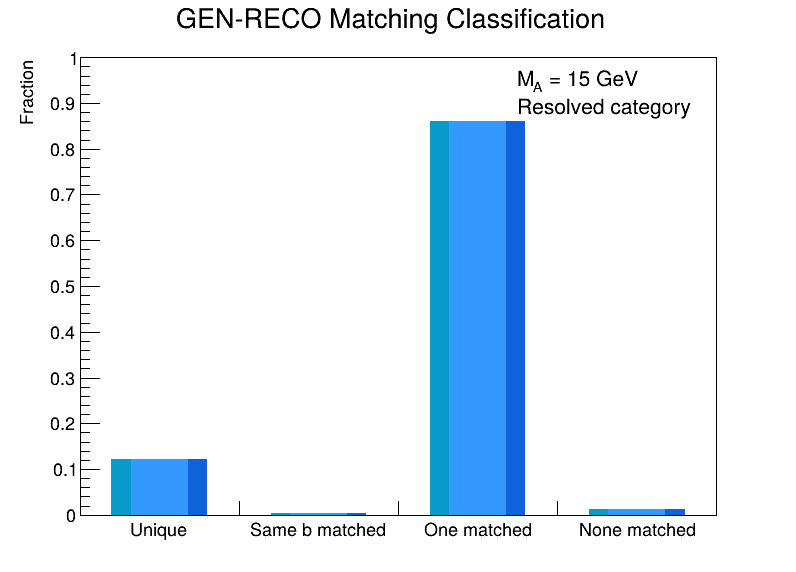

: 

: 

: 

In [ ]:
total = len(dR_matrix)

unique_frac = ak.sum(unique_match) / total
same_frac   = ak.sum(same_b) / total
one_frac    = ak.sum(ak.sum(matched, axis=1) == 1) / total
none_frac   = ak.sum(ak.sum(matched, axis=1) == 0) / total

ROOT.gStyle.SetOptStat(0)

c = ROOT.TCanvas("c","Matching Fractions",800,600)

h = ROOT.TH1F("h","GEN-RECO Matching Classification",
              4, 0.5, 4.5)

h.GetXaxis().SetBinLabel(1,"Unique")
h.GetXaxis().SetBinLabel(2,"Same b matched")
h.GetXaxis().SetBinLabel(3,"One matched")
h.GetXaxis().SetBinLabel(4,"None matched")
h.GetXaxis().SetLabelSize(0.05)
h.GetYaxis().SetTitle("Fraction")


h.SetBinContent(1, unique_frac)
h.SetBinContent(2, same_frac)
h.SetBinContent(3, one_frac)
h.SetBinContent(4, none_frac)

h.SetMaximum(1.0)
h.SetFillColor(ROOT.kAzure+1)
h.SetBarWidth(0.6)
h.SetBarOffset(0.2)

h.Draw("bar2")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.65, 0.85, f"M_{{A}} = {M} GeV")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.65, 0.80, f"Resolved category")

c.Draw()

c.SaveAs(Plot_dir+f"resolved_cat_matching_fraction_{M}.png")

In [ ]:
dijet = lead_bjet+sublead_bjet

: 

: 

: 

In [ ]:
m_bb=dijet.mass

: 

: 

: 

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Jets/btag_wp_optimization/lower_cut/m_bb_15.png has been created


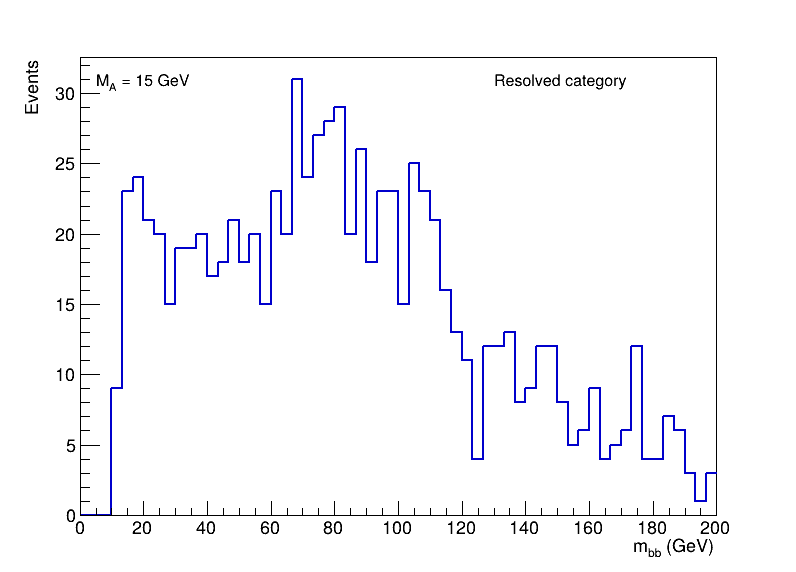

: 

: 

: 

In [ ]:
ROOT.gStyle.SetOptStat(0)

# Convert to numpy
m_bb_np = ak.to_numpy(m_bb)

# Create histogram
h = ROOT.TH1F("h",
              ";m_{bb} (GeV);Events",
              60, 0, 200)

# Fill
for val in m_bb_np:
    h.Fill(val)


# Draw
c = ROOT.TCanvas("c","m_bb",800,600)
h.SetLineColor(ROOT.kBlue+1)
h.SetLineWidth(2)
h.Draw("hist")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.12, 0.85, f"M_{{A}} = {M} GeV")

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.03)
latex.SetTextFont(42)
latex.DrawLatex(0.62, 0.85, "Resolved category")

c.Draw()

c.SaveAs(Plot_dir+f"m_bb_{M}.png")
